In [54]:
import pandas as pd
import os


from utils.utils import PolicyEDA, EmissionsDataProcessor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
eda_utils = PolicyEDA()

In [4]:
SCRIPT_DIR_PATH = os.getcwd()
ROOT_DIR_PATH = os.path.dirname(SCRIPT_DIR_PATH)
DATA_DIR_PATH = os.path.join(ROOT_DIR_PATH, "data")
PROCESSED_DATA_DIR_PATH = os.path.join(DATA_DIR_PATH, "processed_data")
RESULTS_DIR_PATH = os.path.join(SCRIPT_DIR_PATH, "results")

In [5]:
# import IEA scored data
policy_df = pd.read_csv(os.path.join(PROCESSED_DATA_DIR_PATH, "IEA_scored_cpsi.csv"))
policy_df.head()

,iso_alpha_3,year,avg_policy_score,policy_count,dominant_topic,dominant_category,log_policy_count,CPSI,CPSI_power_3,CPSI_geom_4,CPSI_geom_7
0,AFG,1971,0.75,1,Energy,Solar Power,0.693147,0.51986,0.644646,1.490182,1.643752
1,AFG,1972,0.75,1,Energy,Solar Power,0.693147,0.51986,0.644646,1.490182,1.643752
2,AFG,1973,0.75,1,Energy,Solar Power,0.693147,0.51986,0.644646,1.490182,1.643752
3,AFG,1974,0.75,1,Energy,Solar Power,0.693147,0.51986,0.644646,1.490182,1.643752
4,AFG,1975,0.75,1,Energy,Solar Power,0.693147,0.51986,0.644646,1.490182,1.643752


In [6]:
policy_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9255 entries, 0 to 9254
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   iso_alpha_3        9255 non-null   object 
 1   year               9255 non-null   int64  
 2   avg_policy_score   9255 non-null   float64
 3   policy_count       9255 non-null   int64  
 4   dominant_topic     9255 non-null   object 
 5   dominant_category  9255 non-null   object 
 6   log_policy_count   9255 non-null   float64
 7   CPSI               9255 non-null   float64
 8   CPSI_power_3       9255 non-null   float64
 9   CPSI_geom_4        9255 non-null   float64
 10  CPSI_geom_7        9255 non-null   float64
dtypes: float64(6), int64(2), object(3)
memory usage: 795.5+ KB


In [7]:
# import emissions data
emissions_df = pd.read_csv(os.path.join(PROCESSED_DATA_DIR_PATH, "total_emissions.csv"))
emissions_df.head()

,iso_alpha_3,income_group,region,year,total_emissions
0,ABW,High income,Latin America & Caribbean,2000,0.335765
1,ABW,High income,Latin America & Caribbean,2001,0.344135
2,ABW,High income,Latin America & Caribbean,2002,0.363222
3,ABW,High income,Latin America & Caribbean,2003,0.412246
4,ABW,High income,Latin America & Caribbean,2004,0.430187


In [8]:
emissions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4485 entries, 0 to 4484
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   iso_alpha_3      4485 non-null   object 
 1   income_group     4485 non-null   object 
 2   region           4485 non-null   object 
 3   year             4485 non-null   int64  
 4   total_emissions  4485 non-null   float64
dtypes: float64(1), int64(1), object(3)
memory usage: 175.3+ KB


In [9]:
# import wb controls
wb_controls_df = pd.read_csv(os.path.join(PROCESSED_DATA_DIR_PATH, "wb_control_vars.csv"))
wb_controls_df.head()

,year,gdp_2015_usd,population,energy_per_capita,renewable_share,energy_intensity,urbanization_rate,industry_size,forest_area,iso_alpha_3
0,2022,1.040350e+12,731821393.0,565.488909,NaN,7.303970,37.909012,26.921919,29.737205,NaN
1,2021,1.004646e+12,713090928.0,570.998888,NaN,7.156658,37.393633,26.075267,29.955194,NaN
2,2020,9.606813e+11,694446100.0,563.976201,66.123449,7.107927,36.884034,25.434235,30.174252,NaN
3,2019,9.890095e+11,675950189.0,586.441491,63.387090,7.212707,36.384272,26.421751,30.391626,NaN
4,2018,9.677734e+11,657801085.0,583.763039,62.242631,7.273489,35.893398,27.859732,30.611512,NaN


In [10]:
wb_controls_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6118 entries, 0 to 6117
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   year               6118 non-null   int64  
 1   gdp_2015_usd       5832 non-null   float64
 2   population         6095 non-null   float64
 3   energy_per_capita  4565 non-null   float64
 4   renewable_share    5710 non-null   float64
 5   energy_intensity   4404 non-null   float64
 6   urbanization_rate  6049 non-null   float64
 7   industry_size      5551 non-null   float64
 8   forest_area        5953 non-null   float64
 9   iso_alpha_3        4945 non-null   object 
dtypes: float64(8), int64(1), object(1)
memory usage: 478.1+ KB


In [11]:
global_policy_emissions_df = pd.merge(policy_df, emissions_df, on=["iso_alpha_3", "year"], how="inner")
global_policy_emissions_df.head()

,iso_alpha_3,year,avg_policy_score,policy_count,dominant_topic,dominant_category,log_policy_count,CPSI,CPSI_power_3,CPSI_geom_4,CPSI_geom_7,income_group,region,total_emissions
0,AFG,2000,0.75,1,Energy,Solar Power,0.693147,0.51986,0.644646,1.490182,1.643752,Low income,South Asia,25.390391
1,AFG,2001,0.75,1,Energy,Solar Power,0.693147,0.51986,0.644646,1.490182,1.643752,Low income,South Asia,23.723115
2,AFG,2002,0.75,1,Energy,Solar Power,0.693147,0.51986,0.644646,1.490182,1.643752,Low income,South Asia,26.383509
3,AFG,2003,0.75,1,Energy,Solar Power,0.693147,0.51986,0.644646,1.490182,1.643752,Low income,South Asia,27.071538
4,AFG,2004,0.75,1,Energy,Solar Power,0.693147,0.51986,0.644646,1.490182,1.643752,Low income,South Asia,27.128799


In [12]:
# check if USA is in the data
global_policy_emissions_df[global_policy_emissions_df["iso_alpha_3"] == "USA"].head()

,iso_alpha_3,year,avg_policy_score,policy_count,dominant_topic,dominant_category,log_policy_count,CPSI,CPSI_power_3,CPSI_geom_4,CPSI_geom_7,income_group,region,total_emissions
3965,USA,2000,0.459459,74,Cross-cutting / Economy-wide,Other,4.317488,1.983711,9.446749,16.263613,27.070635,High income,North America,6318.595153
3966,USA,2001,0.460366,82,Cross-cutting / Economy-wide,Other,4.418841,2.034283,10.106958,17.469706,29.368590,High income,North America,6237.645614
3967,USA,2002,0.446809,94,Cross-cutting / Economy-wide,Other,4.553877,2.034711,10.700017,19.030183,32.523942,High income,North America,6102.809992
3968,USA,2003,0.444175,103,Cross-cutting / Economy-wide,Other,4.644391,2.062921,11.271911,20.239021,34.925083,High income,North America,6142.901629
3969,USA,2004,0.461864,118,Cross-cutting / Economy-wide,Other,4.779123,2.207307,12.772495,22.502834,39.204911,High income,North America,6313.734481


In [13]:
# Safety check to ensure USA is in the data
wb_controls_df[wb_controls_df["iso_alpha_3"] == "USA"].head()

,year,gdp_2015_usd,population,energy_per_capita,renewable_share,energy_intensity,urbanization_rate,industry_size,forest_area,iso_alpha_3
5865,2022,2.144339e+13,333271411.0,6520.176697,NaN,11.171772,83.084,NaN,33.866926,USA
5866,2021,2.091785e+13,332048977.0,6441.742879,10.9,11.071275,82.873,17.608172,33.866926,USA
5867,2020,1.972358e+13,331526933.0,6138.375293,11.0,10.972348,82.664,17.267677,33.866926,USA
5868,2019,2.015964e+13,328329953.0,6736.457903,10.2,10.318741,82.459,18.145484,33.866926,USA
5869,2018,1.965187e+13,326838199.0,6770.788961,9.9,10.053513,82.256,18.519546,33.866926,USA


In [14]:
# Now let's merge the wb controls data
global_policy_emissions_df = pd.merge(global_policy_emissions_df, wb_controls_df, on=["iso_alpha_3", "year"], how="inner")
global_policy_emissions_df.head()

,iso_alpha_3,year,avg_policy_score,policy_count,dominant_topic,dominant_category,log_policy_count,CPSI,CPSI_power_3,CPSI_geom_4,...,region,total_emissions,gdp_2015_usd,population,energy_per_capita,renewable_share,energy_intensity,urbanization_rate,industry_size,forest_area
0,AFG,2000,0.75,1,Energy,Solar Power,0.693147,0.51986,0.644646,1.490182,...,South Asia,25.390391,6.206548e+09,20130327.0,NaN,45.0,NaN,22.078,NaN,1.852782
1,AFG,2001,0.75,1,Energy,Solar Power,0.693147,0.51986,0.644646,1.490182,...,South Asia,23.723115,5.621148e+09,20284307.0,NaN,45.6,NaN,22.169,NaN,1.852782
2,AFG,2002,0.75,1,Energy,Solar Power,0.693147,0.51986,0.644646,1.490182,...,South Asia,26.383509,7.228796e+09,21378117.0,NaN,37.8,NaN,22.261,23.810127,1.852782
3,AFG,2003,0.75,1,Energy,Solar Power,0.693147,0.51986,0.644646,1.490182,...,South Asia,27.071538,7.867263e+09,22733049.0,NaN,36.7,NaN,22.353,22.710864,1.852782
4,AFG,2004,0.75,1,Energy,Solar Power,0.693147,0.51986,0.644646,1.490182,...,South Asia,27.128799,7.978516e+09,23560654.0,NaN,44.2,NaN,22.500,26.226790,1.852782


In [15]:
# check if USA is in the data
global_policy_emissions_df[global_policy_emissions_df["iso_alpha_3"] == "USA"].head()


,iso_alpha_3,year,avg_policy_score,policy_count,dominant_topic,dominant_category,log_policy_count,CPSI,CPSI_power_3,CPSI_geom_4,...,region,total_emissions,gdp_2015_usd,population,energy_per_capita,renewable_share,energy_intensity,urbanization_rate,industry_size,forest_area
3943,USA,2000,0.459459,74,Cross-cutting / Economy-wide,Other,4.317488,1.983711,9.446749,16.263613,...,North America,6318.595153,1.371768e+13,282162411.0,8055.145489,5.4,6.832729,79.057,22.451577,33.130174
3944,USA,2001,0.460366,82,Cross-cutting / Economy-wide,Other,4.418841,2.034283,10.106958,17.469706,...,North America,6237.645614,1.384876e+13,284968955.0,7824.243939,4.7,7.031645,79.234,21.469006,33.186756
3945,USA,2002,0.446809,94,Cross-cutting / Economy-wide,Other,4.553877,2.034711,10.700017,19.030183,...,North America,6102.809992,1.408425e+13,287625193.0,7840.460959,4.8,7.070518,79.409,20.652475,33.243338
3946,USA,2003,0.444175,103,Cross-cutting / Economy-wide,Other,4.644391,2.062921,11.271911,20.239021,...,North America,6142.901629,1.447799e+13,290107933.0,7791.303915,5.3,7.251444,79.583,20.739462,33.299920
3947,USA,2004,0.461864,118,Cross-cutting / Economy-wide,Other,4.779123,2.207307,12.772495,22.502834,...,North America,6313.734481,1.503507e+13,292805298.0,7878.537171,5.5,7.378481,79.757,20.950032,33.356502


In [16]:
## remove unnecessary columns
global_policy_emissions_df = global_policy_emissions_df.drop(columns=["avg_policy_score", 
                                                        "policy_count", 
                                                        "dominant_topic",
                                                        "dominant_category",
                                                        "log_policy_count"
                    ])

# move total_emissions to the end
global_policy_emissions_df = global_policy_emissions_df[[col for col in global_policy_emissions_df.columns if col != "total_emissions"] + ["total_emissions"]]
global_policy_emissions_df.head()

,iso_alpha_3,year,CPSI,CPSI_power_3,CPSI_geom_4,CPSI_geom_7,income_group,region,gdp_2015_usd,population,energy_per_capita,renewable_share,energy_intensity,urbanization_rate,industry_size,forest_area,total_emissions
0,AFG,2000,0.51986,0.644646,1.490182,1.643752,Low income,South Asia,6.206548e+09,20130327.0,NaN,45.0,NaN,22.078,NaN,1.852782,25.390391
1,AFG,2001,0.51986,0.644646,1.490182,1.643752,Low income,South Asia,5.621148e+09,20284307.0,NaN,45.6,NaN,22.169,NaN,1.852782,23.723115
2,AFG,2002,0.51986,0.644646,1.490182,1.643752,Low income,South Asia,7.228796e+09,21378117.0,NaN,37.8,NaN,22.261,23.810127,1.852782,26.383509
3,AFG,2003,0.51986,0.644646,1.490182,1.643752,Low income,South Asia,7.867263e+09,22733049.0,NaN,36.7,NaN,22.353,22.710864,1.852782,27.071538
4,AFG,2004,0.51986,0.644646,1.490182,1.643752,Low income,South Asia,7.978516e+09,23560654.0,NaN,44.2,NaN,22.500,26.226790,1.852782,27.128799


In [17]:
global_policy_emissions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4165 entries, 0 to 4164
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   iso_alpha_3        4165 non-null   object 
 1   year               4165 non-null   int64  
 2   CPSI               4165 non-null   float64
 3   CPSI_power_3       4165 non-null   float64
 4   CPSI_geom_4        4165 non-null   float64
 5   CPSI_geom_7        4165 non-null   float64
 6   income_group       4165 non-null   object 
 7   region             4165 non-null   object 
 8   gdp_2015_usd       4092 non-null   float64
 9   population         4165 non-null   float64
 10  energy_per_capita  3353 non-null   float64
 11  renewable_share    4028 non-null   float64
 12  energy_intensity   3257 non-null   float64
 13  urbanization_rate  4165 non-null   float64
 14  industry_size      3994 non-null   float64
 15  forest_area        4126 non-null   float64
 16  total_emissions    4165 

In [18]:
oecd_countries_iso3 = eda_utils.get_oecd_iso_codes()
oecd_policy_emissions_df = global_policy_emissions_df[global_policy_emissions_df["iso_alpha_3"].isin(oecd_countries_iso3)].reset_index(drop=True)
oecd_policy_emissions_df.head()

,iso_alpha_3,year,CPSI,CPSI_power_3,CPSI_geom_4,CPSI_geom_7,income_group,region,gdp_2015_usd,population,energy_per_capita,renewable_share,energy_intensity,urbanization_rate,industry_size,forest_area,total_emissions
0,AUS,2000,1.646963,5.745594,9.562867,14.737193,High income,East Asia & Pacific,8.726517e+11,19028802.0,5681.228859,8.4,7.923112,84.235,24.550533,17.158156,581.422036
1,AUS,2001,1.868549,6.592434,10.105788,15.434088,High income,East Asia & Pacific,8.903238e+11,19274701.0,5486.394559,8.4,8.263839,84.100,23.633521,17.128633,602.437642
2,AUS,2002,1.892528,6.823265,10.488593,16.109152,High income,East Asia & Pacific,9.257550e+11,19495210.0,5480.234643,8.7,8.505064,84.222,23.611732,17.099111,606.209253
3,AUS,2003,2.119532,7.955850,11.544264,17.755269,High income,East Asia & Pacific,9.543678e+11,19720737.0,5615.576756,7.2,8.458763,84.343,24.042096,17.069589,607.749769
4,AUS,2004,2.201468,9.152636,13.653080,21.591609,High income,East Asia & Pacific,9.946831e+11,19932722.0,5652.130379,6.7,8.665917,84.463,23.934919,17.040066,608.183791


In [19]:
oecd_policy_emissions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 847 entries, 0 to 846
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   iso_alpha_3        847 non-null    object 
 1   year               847 non-null    int64  
 2   CPSI               847 non-null    float64
 3   CPSI_power_3       847 non-null    float64
 4   CPSI_geom_4        847 non-null    float64
 5   CPSI_geom_7        847 non-null    float64
 6   income_group       847 non-null    object 
 7   region             847 non-null    object 
 8   gdp_2015_usd       847 non-null    float64
 9   population         847 non-null    float64
 10  energy_per_capita  847 non-null    float64
 11  renewable_share    810 non-null    float64
 12  energy_intensity   847 non-null    float64
 13  urbanization_rate  847 non-null    float64
 14  industry_size      843 non-null    float64
 15  forest_area        846 non-null    float64
 16  total_emissions    847 non

In [20]:
# safety check to ensure USA is in the data
oecd_policy_emissions_df[oecd_policy_emissions_df["iso_alpha_3"] == "USA"].head()

,iso_alpha_3,year,CPSI,CPSI_power_3,CPSI_geom_4,CPSI_geom_7,income_group,region,gdp_2015_usd,population,energy_per_capita,renewable_share,energy_intensity,urbanization_rate,industry_size,forest_area,total_emissions
824,USA,2000,1.983711,9.446749,16.263613,27.070635,High income,North America,1.371768e+13,282162411.0,8055.145489,5.4,6.832729,79.057,22.451577,33.130174,6318.595153
825,USA,2001,2.034283,10.106958,17.469706,29.368590,High income,North America,1.384876e+13,284968955.0,7824.243939,4.7,7.031645,79.234,21.469006,33.186756,6237.645614
826,USA,2002,2.034711,10.700017,19.030183,32.523942,High income,North America,1.408425e+13,287625193.0,7840.460959,4.8,7.070518,79.409,20.652475,33.243338,6102.809992
827,USA,2003,2.062921,11.271911,20.239021,34.925083,High income,North America,1.447799e+13,290107933.0,7791.303915,5.3,7.251444,79.583,20.739462,33.299920,6142.901629
828,USA,2004,2.207307,12.772495,22.502834,39.204911,High income,North America,1.503507e+13,292805298.0,7878.537171,5.5,7.378481,79.757,20.950032,33.356502,6313.734481


## Data Cleaning

In [21]:
feats_to_keep = ["iso_alpha_3", "year", "income_group", "region", "CPSI_geom_7", "gdp_2015_usd", "population", "total_emissions"]
global_policy_emissions_df = global_policy_emissions_df[feats_to_keep]

# Rename index to CPSI
global_policy_emissions_df = global_policy_emissions_df.rename(columns={"CPSI_geom_7": "CPSI"})
print(global_policy_emissions_df.head())

  iso_alpha_3  year income_group      region      CPSI  gdp_2015_usd  \
0         AFG  2000   Low income  South Asia  1.643752  6.206548e+09   
1         AFG  2001   Low income  South Asia  1.643752  5.621148e+09   
2         AFG  2002   Low income  South Asia  1.643752  7.228796e+09   
3         AFG  2003   Low income  South Asia  1.643752  7.867263e+09   
4         AFG  2004   Low income  South Asia  1.643752  7.978516e+09   

   population  total_emissions  
0  20130327.0        25.390391  
1  20284307.0        23.723115  
2  21378117.0        26.383509  
3  22733049.0        27.071538  
4  23560654.0        27.128799  


In [22]:
global_policy_emissions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4165 entries, 0 to 4164
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   iso_alpha_3      4165 non-null   object 
 1   year             4165 non-null   int64  
 2   income_group     4165 non-null   object 
 3   region           4165 non-null   object 
 4   CPSI             4165 non-null   float64
 5   gdp_2015_usd     4092 non-null   float64
 6   population       4165 non-null   float64
 7   total_emissions  4165 non-null   float64
dtypes: float64(4), int64(1), object(3)
memory usage: 260.4+ KB


In [23]:
# Get the subset df where gdp_2015_usd is null
gdp_null_df = global_policy_emissions_df[global_policy_emissions_df["gdp_2015_usd"].isnull()]
gdp_null_df.iso_alpha_3.unique()

array(['DJI', 'ERI', 'FRO', 'GRL', 'NCL', 'PRK', 'YEM'], dtype=object)

In [24]:
global_policy_emissions_df = global_policy_emissions_df.dropna(subset=["gdp_2015_usd"])

In [25]:
# Check how many records we have per iso_alpha_3 and create a new df
# with the number of records per iso_alpha_3
iso_alpha_3_counts = global_policy_emissions_df["iso_alpha_3"].value_counts().reset_index()
iso_alpha_3_counts.columns = ["iso_alpha_3", "count"]
iso_alpha_3_counts = iso_alpha_3_counts.sort_values(by="count", ascending=False)

# how many countries have less than x records?
x = 23
countries_with_less_than_x_records = iso_alpha_3_counts[iso_alpha_3_counts["count"] < x]
print(f"Countries with less than {x} records: {countries_with_less_than_x_records.shape[0]}")
print(countries_with_less_than_x_records)

Countries with less than 23 records: 31
    iso_alpha_3  count
157         ALB     21
158         BIH     20
159         BGR     20
160         WSM     20
161         HKG     20
162         GNQ     20
163         TON     20
164         CYP     20
165         YEM     19
166         SVK     19
167         VCT     18
168         GRD     18
169         BHS     18
170         ATG     18
171         DMA     18
172         KNA     18
173         JAM     18
174         LCA     18
175         MDV     17
176         BRN     17
177         SYC     16
178         GRL     15
179         FRO     15
180         ERI     12
181         DJI     10
182         CYM      9
183         BMU      9
184         PYF      9
185         MAC      6
186         PLW      2
187         NCL      1


In [26]:
# Remove the countries with less than x records from the global_policy_emissions_df
countries_to_remove = countries_with_less_than_x_records["iso_alpha_3"].tolist()
global_policy_emissions_df = global_policy_emissions_df[~global_policy_emissions_df["iso_alpha_3"].isin(countries_to_remove)]
global_policy_emissions_df = global_policy_emissions_df.reset_index(drop=True)

In [27]:
# Check the max year for every country
max_year_df = global_policy_emissions_df.groupby("iso_alpha_3")["year"].max().reset_index()
max_year_df.columns = ["iso_alpha_3", "max_year"]
max_year_df = max_year_df.sort_values(by="max_year", ascending=False)
print(max_year_df)

    iso_alpha_3  max_year
0           AFG      2022
1           AGO      2022
2           ARE      2022
3           ARG      2022
4           ARM      2022
..          ...       ...
152         VNM      2022
153         VUT      2022
154         ZAF      2022
155         ZMB      2022
156         ZWE      2022

[157 rows x 2 columns]


In [28]:
countries_with_max_year_less_than_2015 = max_year_df[max_year_df["max_year"] < 2015]
print(f"Countries with max year less than 2015: {countries_with_max_year_less_than_2015.shape[0]}")
print(countries_with_max_year_less_than_2015)
# Remove the countries with max year less than 2015 from the global_policy_emissions_df
countries_to_remove = countries_with_max_year_less_than_2015["iso_alpha_3"].tolist()
global_policy_emissions_df = global_policy_emissions_df[~global_policy_emissions_df["iso_alpha_3"].isin(countries_to_remove)]
global_policy_emissions_df = global_policy_emissions_df.reset_index(drop=True)

Countries with max year less than 2015: 0
Empty DataFrame
Columns: [iso_alpha_3, max_year]
Index: []


In [29]:
global_policy_emissions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3611 entries, 0 to 3610
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   iso_alpha_3      3611 non-null   object 
 1   year             3611 non-null   int64  
 2   income_group     3611 non-null   object 
 3   region           3611 non-null   object 
 4   CPSI             3611 non-null   float64
 5   gdp_2015_usd     3611 non-null   float64
 6   population       3611 non-null   float64
 7   total_emissions  3611 non-null   float64
dtypes: float64(4), int64(1), object(3)
memory usage: 225.8+ KB


In [30]:
def check_discontinuous_years(df):
    discontinuous_years = []
    for iso_alpha_3 in df["iso_alpha_3"].unique():
        country_df = df[df["iso_alpha_3"] == iso_alpha_3]
        years = sorted(country_df["year"].tolist())
        years_range = list(range(min(years), max(years) + 1))
        if years != years_range:
            print(f"Discontinuous years for {iso_alpha_3}: {years_range} vs {years}")
            discontinuous_years.append(iso_alpha_3)
    return discontinuous_years

discontinuous_years = check_discontinuous_years(global_policy_emissions_df)
print(f"Countries with discontinuous years: {len(discontinuous_years)}")
print(discontinuous_years)

Countries with discontinuous years: 0
[]


In [31]:
# Check for duplicates
duplicates_df = global_policy_emissions_df[global_policy_emissions_df.duplicated(subset=["iso_alpha_3", "year"], keep=False)]
duplicates_df = duplicates_df.sort_values(by=["iso_alpha_3", "year"])
print(f"Duplicates: {duplicates_df.shape[0]}")
print(duplicates_df)

Duplicates: 0
Empty DataFrame
Columns: [iso_alpha_3, year, income_group, region, CPSI, gdp_2015_usd, population, total_emissions]
Index: []


In [32]:
# Check for negative values in total_emissions
negative_emissions_df = global_policy_emissions_df[global_policy_emissions_df["total_emissions"] < 0]
print(f"Negative emissions: {negative_emissions_df.shape[0]}")
print(negative_emissions_df)

Negative emissions: 354
     iso_alpha_3  year         income_group                       region  \
184          BDI  2000           Low income  Africa Eastern and Southern   
185          BDI  2001           Low income  Africa Eastern and Southern   
186          BDI  2002           Low income  Africa Eastern and Southern   
187          BDI  2003           Low income  Africa Eastern and Southern   
188          BDI  2004           Low income  Africa Eastern and Southern   
...          ...   ...                  ...                          ...   
3537         VUT  2018  Lower middle income          East Asia & Pacific   
3538         VUT  2019  Lower middle income          East Asia & Pacific   
3539         VUT  2020  Lower middle income          East Asia & Pacific   
3540         VUT  2021  Lower middle income          East Asia & Pacific   
3541         VUT  2022  Lower middle income          East Asia & Pacific   

          CPSI  gdp_2015_usd  population  total_emissions  
184

In [33]:
# Remove iso_alpha_3 with negative emissions
countries_to_remove = negative_emissions_df["iso_alpha_3"].unique().tolist()
global_policy_emissions_df = global_policy_emissions_df[~global_policy_emissions_df["iso_alpha_3"].isin(countries_to_remove)]
global_policy_emissions_df = global_policy_emissions_df.reset_index(drop=True)
global_policy_emissions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3105 entries, 0 to 3104
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   iso_alpha_3      3105 non-null   object 
 1   year             3105 non-null   int64  
 2   income_group     3105 non-null   object 
 3   region           3105 non-null   object 
 4   CPSI             3105 non-null   float64
 5   gdp_2015_usd     3105 non-null   float64
 6   population       3105 non-null   float64
 7   total_emissions  3105 non-null   float64
dtypes: float64(4), int64(1), object(3)
memory usage: 194.2+ KB


In [34]:
global_policy_emissions_df.iso_alpha_3.unique().shape

(135,)

## Feature Engineering

In [35]:
global_policy_emissions_df.columns

Index(['iso_alpha_3', 'year', 'income_group', 'region', 'CPSI', 'gdp_2015_usd',
       'population', 'total_emissions'],
      dtype='object')

In [36]:
# We drop population it doesn't seem to be useful
global_policy_emissions_df = global_policy_emissions_df.drop(columns=["population"])

In [37]:
global_policy_emissions_df

,iso_alpha_3,year,income_group,region,CPSI,gdp_2015_usd,total_emissions
0,AFG,2000,Low income,South Asia,1.643752,6.206548e+09,25.390391
1,AFG,2001,Low income,South Asia,1.643752,5.621148e+09,23.723115
2,AFG,2002,Low income,South Asia,1.643752,7.228796e+09,26.383509
3,AFG,2003,Low income,South Asia,1.643752,7.867263e+09,27.071538
4,AFG,2004,Low income,South Asia,1.643752,7.978516e+09,27.128799
...,...,...,...,...,...,...,...
3100,ZWE,2018,Lower middle income,Africa Eastern and Southern,6.621055,2.201518e+10,47.509033
3101,ZWE,2019,Lower middle income,Africa Eastern and Southern,7.084850,2.062108e+10,46.442562
3102,ZWE,2020,Lower middle income,Africa Eastern and Southern,7.084850,1.900914e+10,44.576343
3103,ZWE,2021,Lower middle income,Africa Eastern and Southern,7.803068,2.061884e+10,45.759664


In [38]:
global_policy_emissions_df["is_oecd"] = global_policy_emissions_df["iso_alpha_3"].isin(oecd_countries_iso3).astype(int)

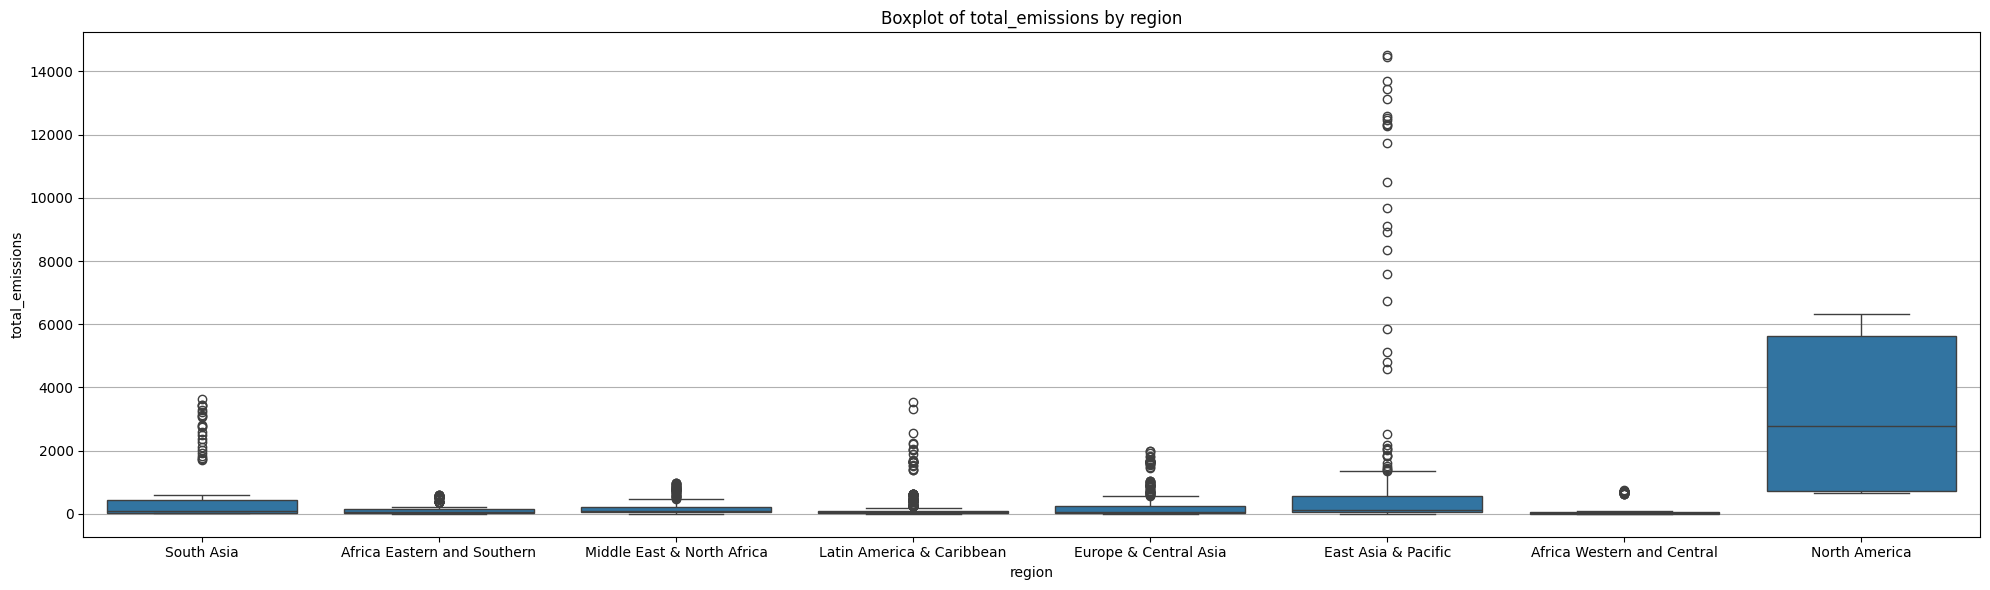

In [39]:
eda_utils.plot_boxplot_by_class(global_policy_emissions_df, "total_emissions", "region", fig_size=(20, 6))

In [40]:
edp = EmissionsDataProcessor(global_policy_emissions_df)

In [41]:
edp.log_transform(columns=['CPSI', 'gdp_2015_usd', 'total_emissions'])
edp.difference_columns(columns=['CPSI', 'gdp_2015_usd', 'total_emissions'], log_first=True)
edp.difference_columns(columns=['dlog_CPSI', 'dlog_gdp_2015_usd', 'dlog_total_emissions'], log_first=False)
edp.difference_columns(columns=['CPSI'], log_first=False)

In [42]:
edp.get_processed_data().head()

,iso_alpha_3,year,income_group,region,CPSI,gdp_2015_usd,total_emissions,is_oecd,log_CPSI,log_gdp_2015_usd,log_total_emissions,dlog_CPSI,dlog_gdp_2015_usd,dlog_total_emissions,diff_dlog_CPSI,diff_dlog_gdp_2015_usd,diff_dlog_total_emissions,diff_CPSI
0,AFG,2000,Low income,South Asia,1.643752,6.206548e+09,25.390391,0,0.496981,22.548871,3.234371,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,AFG,2001,Low income,South Asia,1.643752,5.621148e+09,23.723115,0,0.496981,22.449802,3.166450,0.0,-0.099069,-0.067921,NaN,NaN,NaN,0.0
2,AFG,2002,Low income,South Asia,1.643752,7.228796e+09,26.383509,0,0.496981,22.701338,3.272739,0.0,0.251537,0.106289,0.0,0.350606,0.174210,0.0
3,AFG,2003,Low income,South Asia,1.643752,7.867263e+09,27.071538,0,0.496981,22.785976,3.298483,0.0,0.084638,0.025744,0.0,-0.166899,-0.080546,0.0
4,AFG,2004,Low income,South Asia,1.643752,7.978516e+09,27.128799,0,0.496981,22.800018,3.300596,0.0,0.014042,0.002113,0.0,-0.070596,-0.023631,0.0


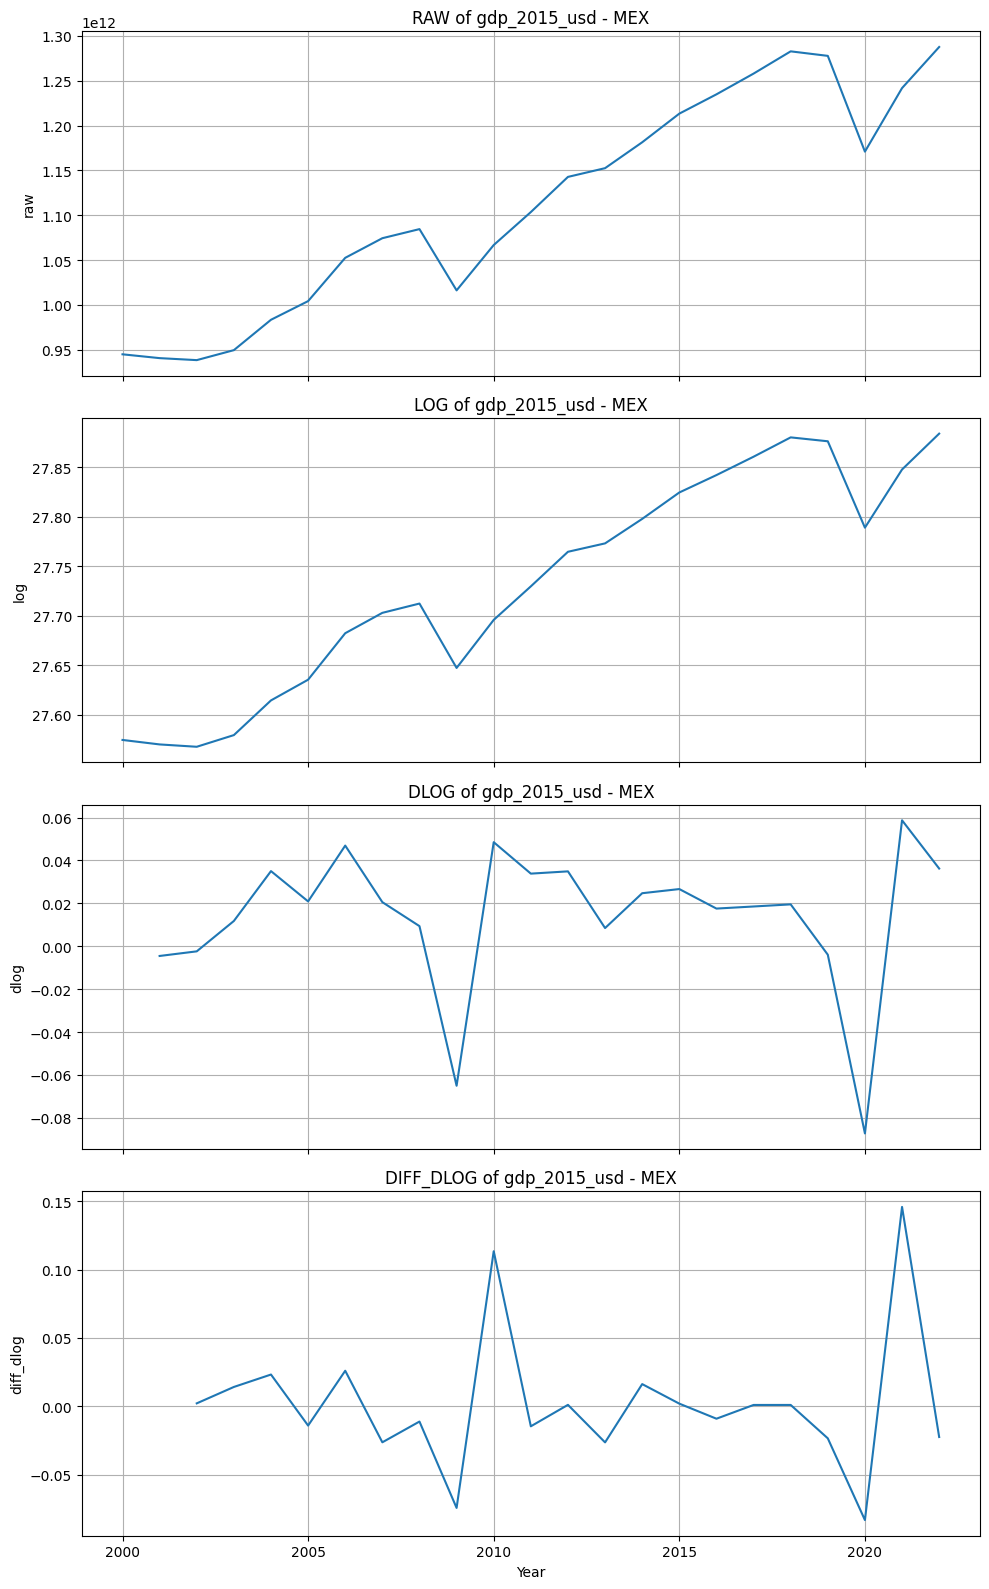

In [43]:
edp.plot_series("gdp_2015_usd", ['MEX'], transformed=True)
# edp.plot_series("population", ['MEX', 'USA', 'UGA'], transformed=True)
# edp.plot_series("CPSI", ['MEX', 'USA', 'UGA'], transformed=True)
# edp.plot_series("total_emissions", ['MEX', 'USA', 'LBN'], transformed=True)

In [ ]:
# The Kwiatkowski-Phillips-Schmidt-Shin (KPSS) test and The Augmented Dickey-Fuller (ADF) test

gdp_test_summary = edp.adf_kpss_test_summary("gdp_2015_usd", global_policy_emissions_df.iso_alpha_3.unique().tolist())
# pop_test_summary = edp.adf_kpss_test_summary("population", global_policy_emissions_df.iso_alpha_3.unique().tolist())
CPSI_test_summary = edp.adf_kpss_test_summary("CPSI", global_policy_emissions_df.iso_alpha_3.unique().tolist())
emissions_test_summary = edp.adf_kpss_test_summary("total_emissions", global_policy_emissions_df.iso_alpha_3.unique().tolist())

/home/tony-ubuntu/decision_sciences/climate_policy_impact_analyzer/ml_scripts/utils/utils.py:783: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_p = kpss(series, nlags='auto')[1]
/home/tony-ubuntu/decision_sciences/climate_policy_impact_analyzer/ml_scripts/utils/utils.py:783: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_p = kpss(series, nlags='auto')[1]
/home/tony-ubuntu/decision_sciences/climate_policy_impact_analyzer/ml_scripts/utils/utils.py:783: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_p = kpss(series, nlags='auto')[1]
/home/tony-ubuntu/decision_sciences/climate_policy_impact_analyzer/ml_scripts/util

In [45]:
summaries_to_check = {
    "gdp_2015_usd": gdp_test_summary,
    # "population": pop_test_summary,
    "CPSI": CPSI_test_summary,
    "total_emissions": emissions_test_summary
}

print("Stationarity test summaries aggrement percentage:")
for var in summaries_to_check.keys():
    print("="*40)
    print(f"Variable: {var}")
    aggrement_percentage = edp.summarize_stationarity_agreement(summaries_to_check[var], var)
    print(aggrement_percentage.to_string())
    print("="*40 + "\n")


Stationarity test summaries aggrement percentage:
Variable: gdp_2015_usd
raw           0.740741
log           2.222222
dlog         47.407407
diff               NaN
diff_dlog    56.296296

Variable: CPSI
raw           0.000000
log           0.740741
dlog         48.888889
diff         33.333333
diff_dlog    49.629630

Variable: total_emissions
raw           4.444444
log           4.444444
dlog         46.666667
diff               NaN
diff_dlog    46.666667



In [46]:
# Keep iso_alpha_3, year, and dlog_ columns
cols_to_lag = [col for col in edp.get_processed_data().columns if col.startswith("dlog_") and "CPSI" not in col]
edp.generate_lags(cols_to_lag, max_lag=1)
edp.generate_lags(["dlog_CPSI"], max_lag=3)
edp.get_processed_data().head()

,iso_alpha_3,year,income_group,region,CPSI,gdp_2015_usd,total_emissions,is_oecd,log_CPSI,log_gdp_2015_usd,...,dlog_total_emissions,diff_dlog_CPSI,diff_dlog_gdp_2015_usd,diff_dlog_total_emissions,diff_CPSI,dlog_gdp_2015_usd_lag1,dlog_total_emissions_lag1,dlog_CPSI_lag1,dlog_CPSI_lag2,dlog_CPSI_lag3
0,AFG,2000,Low income,South Asia,1.643752,6.206548e+09,25.390391,0,0.496981,22.548871,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,AFG,2001,Low income,South Asia,1.643752,5.621148e+09,23.723115,0,0.496981,22.449802,...,-0.067921,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN
2,AFG,2002,Low income,South Asia,1.643752,7.228796e+09,26.383509,0,0.496981,22.701338,...,0.106289,0.0,0.350606,0.174210,0.0,-0.099069,-0.067921,0.0,NaN,NaN
3,AFG,2003,Low income,South Asia,1.643752,7.867263e+09,27.071538,0,0.496981,22.785976,...,0.025744,0.0,-0.166899,-0.080546,0.0,0.251537,0.106289,0.0,0.0,NaN
4,AFG,2004,Low income,South Asia,1.643752,7.978516e+09,27.128799,0,0.496981,22.800018,...,0.002113,0.0,-0.070596,-0.023631,0.0,0.084638,0.025744,0.0,0.0,0.0


In [47]:
dlog_cols = [col for col in edp.get_processed_data().columns if col.startswith("dlog_")]
cols_to_keep = ["iso_alpha_3", "year", "income_group", "region", "is_oecd"] + dlog_cols
preprocessed__df = edp.get_processed_data()[cols_to_keep]
preprocessed__df

,iso_alpha_3,year,income_group,region,is_oecd,dlog_CPSI,dlog_gdp_2015_usd,dlog_total_emissions,dlog_gdp_2015_usd_lag1,dlog_total_emissions_lag1,dlog_CPSI_lag1,dlog_CPSI_lag2,dlog_CPSI_lag3
0,AFG,2000,Low income,South Asia,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,AFG,2001,Low income,South Asia,0,0.000000,-0.099069,-0.067921,NaN,NaN,NaN,NaN,NaN
2,AFG,2002,Low income,South Asia,0,0.000000,0.251537,0.106289,-0.099069,-0.067921,0.000000,NaN,NaN
3,AFG,2003,Low income,South Asia,0,0.000000,0.084638,0.025744,0.251537,0.106289,0.000000,0.000000,NaN
4,AFG,2004,Low income,South Asia,0,0.000000,0.014042,0.002113,0.084638,0.025744,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3100,ZWE,2018,Lower middle income,Africa Eastern and Southern,0,-0.053905,0.048884,0.045166,0.039992,-0.010988,0.053905,0.000000,0.000000
3101,ZWE,2019,Lower middle income,Africa Eastern and Southern,0,0.067704,-0.065418,-0.022704,0.048884,0.045166,-0.053905,0.053905,0.000000
3102,ZWE,2020,Lower middle income,Africa Eastern and Southern,0,0.000000,-0.081394,-0.041013,-0.065418,-0.022704,0.067704,-0.053905,0.053905
3103,ZWE,2021,Lower middle income,Africa Eastern and Southern,0,0.096558,0.081285,0.026200,-0.081394,-0.041013,0.000000,0.067704,-0.053905


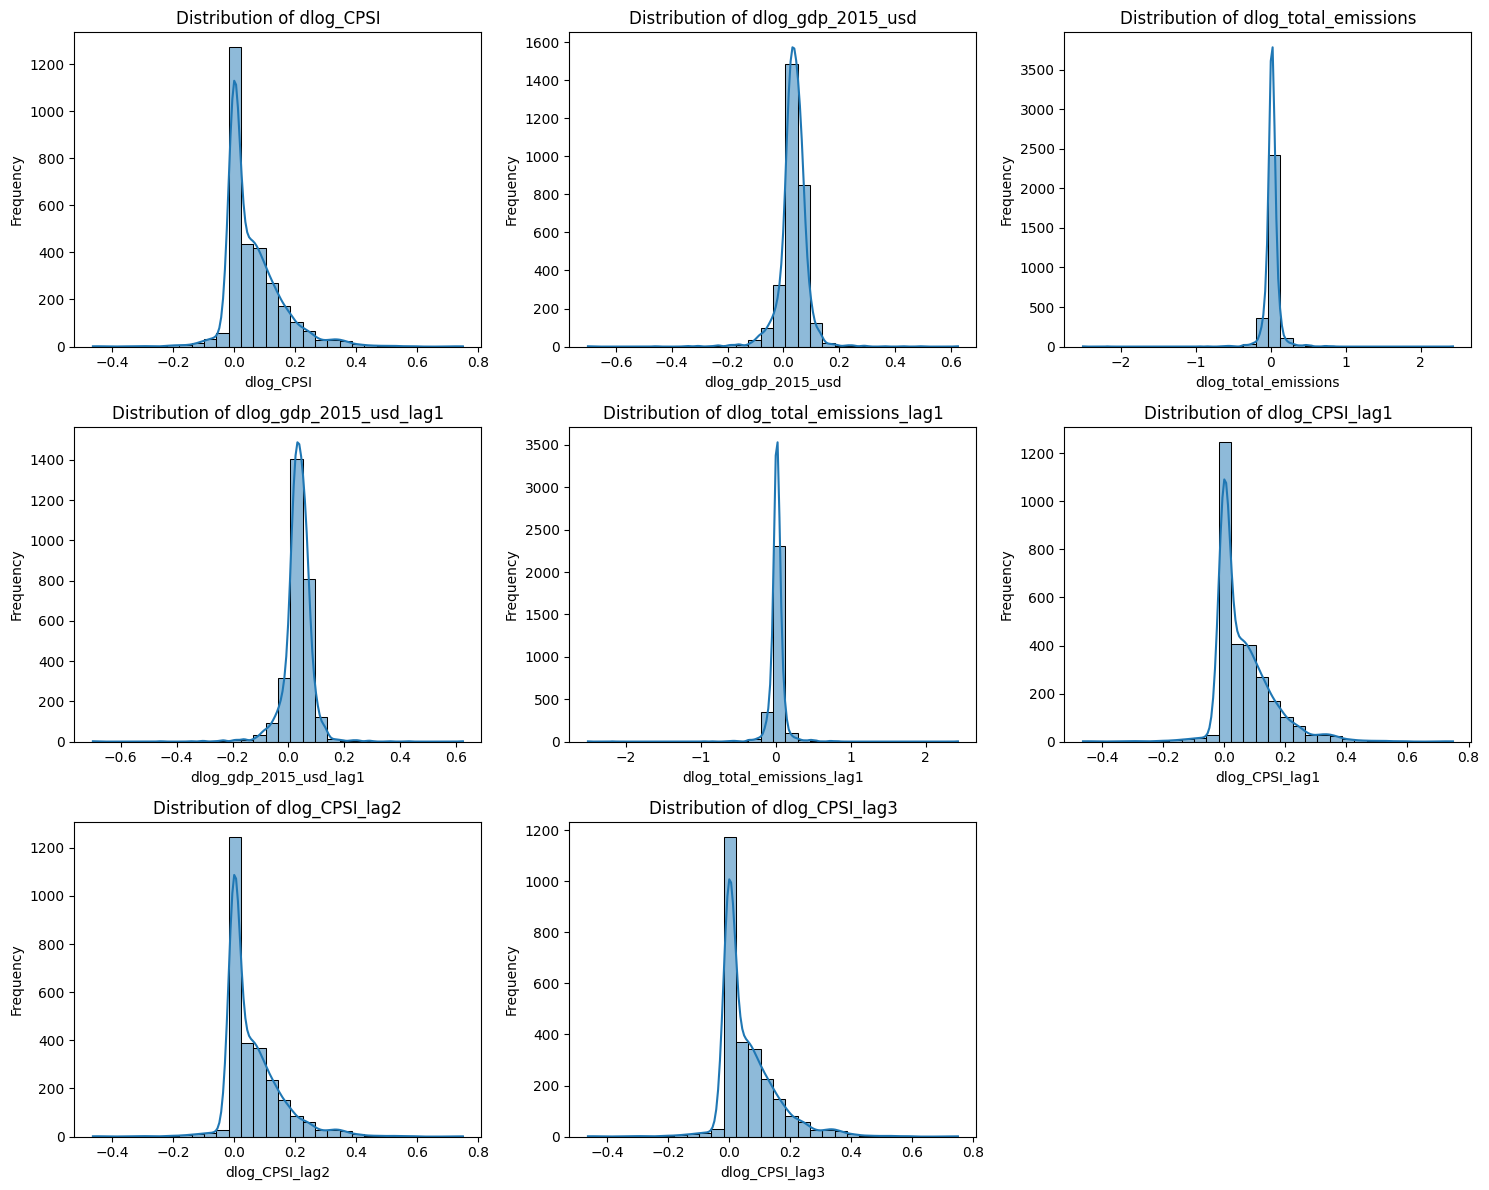

In [48]:
eda_utils.plot_column_distributions(preprocessed__df, dlog_cols)

In [53]:
# # --------------------------------------------------------------------
# # 0.  Imports & helpers
# # --------------------------------------------------------------------
# import pandas as pd
# import numpy as np
# import statsmodels.formula.api as smf
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import mean_absolute_error
# import lightgbm as lgb

# # --------------------------------------------------------------------
# # 1.  Minimal cleaning  (drop rows with missing predictors)
# # --------------------------------------------------------------------
# cols_needed = [
#     # target
#     'dlog_total_emissions',
#     # contemporaneous features
#     'dlog_gdp_2015_usd', 'dlog_CPSI',
#     # lags
#     'dlog_total_emissions_lag1',
#     'dlog_gdp_2015_usd_lag1',
#     'dlog_CPSI_lag1',           'dlog_CPSI_lag2', 'dlog_CPSI_lag3',
#     # fixed descriptors
#     'iso_alpha_3', 'year'
# ]

# df_model = preprocessed__df[cols_needed].dropna().copy()

# # --------------------------------------------------------------------
# # 2.  BASELINE ─ Dynamic-panel linear regression
# #     (country fixed effects  +  year dummies, cluster-robust SE)
# # --------------------------------------------------------------------
# formula = (
#     "dlog_total_emissions ~ "
#     "dlog_total_emissions_lag1 + "
#     "dlog_gdp_2015_usd + dlog_gdp_2015_usd_lag1 + "
#     "dlog_CPSI + dlog_CPSI_lag1 + dlog_CPSI_lag2 + dlog_CPSI_lag3 + "
#     "C(year) + C(iso_alpha_3)"        # fixed effects
# )

# ols_fe = smf.ols(formula, data=df_model).fit(
#     cov_type='cluster', cov_kwds={'groups': df_model['iso_alpha_3']}
# )

# print("\n=== Dynamic-panel baseline (OLS + FE) ===")
# print(ols_fe.summary())      # coefficient table only



In [55]:
# drop the first two years per country where lags are NaN
df = (preprocessed__df
      .sort_values(['iso_alpha_3','year'])
      .groupby('iso_alpha_3')
      .apply(lambda g: g.iloc[4:])  # drop first 4 rows for each country
      .reset_index(drop=True))


#  print(df.isnull().sum())


# Train/test split by year
train = df[df.year <= 2017]
test  = df[(df.year > 2017) & (df.year <= 2022)]

FEATURES = [
    'dlog_CPSI','dlog_gdp_2015_usd',
    'dlog_CPSI_lag1','dlog_CPSI_lag2','dlog_CPSI_lag3',
    'dlog_total_emissions_lag1','dlog_gdp_2015_usd_lag1',
    'is_oecd'
]
CATEGORICAL = ['income_group','region']
NUMERIC = [f for f in FEATURES if f not in CATEGORICAL]

X_train, y_train = train[FEATURES + CATEGORICAL], train['dlog_total_emissions']
X_test,  y_test  = test[FEATURES + CATEGORICAL],  test['dlog_total_emissions']

# Preprocessing
preproc = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), CATEGORICAL),
    ('num', StandardScaler(), NUMERIC),
])

# Define pipelines for each model
pipelines = {
    'rf': Pipeline([('pre', preproc),
                    ('model', RandomForestRegressor(random_state=42))]),
    'gb': Pipeline([('pre', preproc),
                    ('model', GradientBoostingRegressor(random_state=42))]),
    'mlp': Pipeline([('pre', preproc),
                     ('model', MLPRegressor(max_iter=500, random_state=42))]),
}

# Hyperparameter grids
param_grids = {
    'rf': {
        'model__n_estimators': [100, 300],
        'model__max_depth': [5, 10, None],
    },
    'gb': {
        'model__n_estimators': [100, 300],
        'model__learning_rate': [0.01, 0.1],
        'model__max_depth': [3, 5],
    },
    'mlp': {
        'model__hidden_layer_sizes': [(50,50), (100,)],
        'model__alpha': [1e-4, 1e-3],
    },
}

# Time‐series cross‐validation
tscv = TimeSeriesSplit(n_splits=5)

# Grid‐search for each
best_estimators = {}
for name, pipe in pipelines.items():
    gs = GridSearchCV(pipe,
                      param_grids[name],
                      cv=tscv,
                      scoring='neg_mean_absolute_error',
                      n_jobs=-1)
    gs.fit(X_train, y_train)
    best_estimators[name] = gs.best_estimator_
    print(f"{name} best MAE (CV): {-gs.best_score_:.4f}, params: {gs.best_params_}")

# Evaluate on hold‐out 2018–2022
for name, model in best_estimators.items():
    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    print(f"{name} MAE on 2018–22 hold‐out: {mae:.4f}")


/tmp/ipykernel_182939/844897165.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.iloc[4:])  # drop first 4 rows for each country


rf best MAE (CV): 0.0562, params: {'model__max_depth': 5, 'model__n_estimators': 100}
gb best MAE (CV): 0.0525, params: {'model__learning_rate': 0.01, 'model__max_depth': 3, 'model__n_estimators': 100}
mlp best MAE (CV): 0.0828, params: {'model__alpha': 0.0001, 'model__hidden_layer_sizes': (50, 50)}
rf MAE on 2018–22 hold‐out: 0.0365
gb MAE on 2018–22 hold‐out: 0.0365
mlp MAE on 2018–22 hold‐out: 0.0563


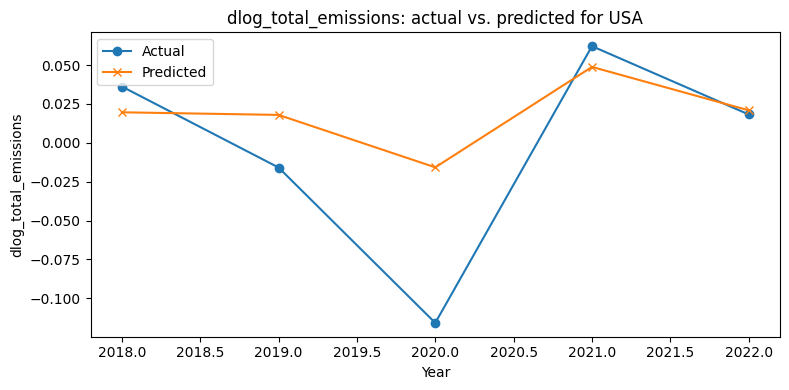

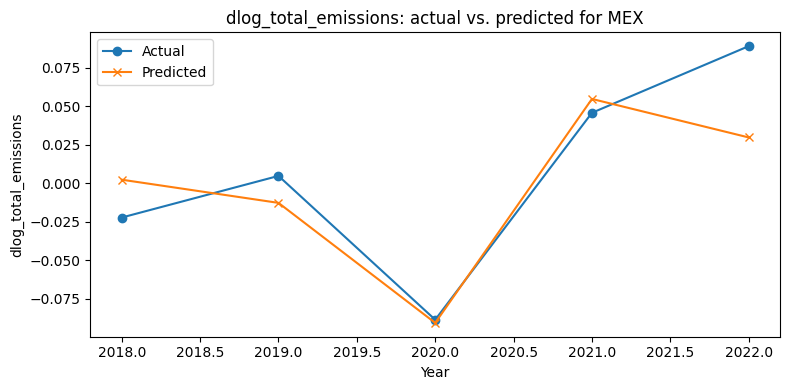

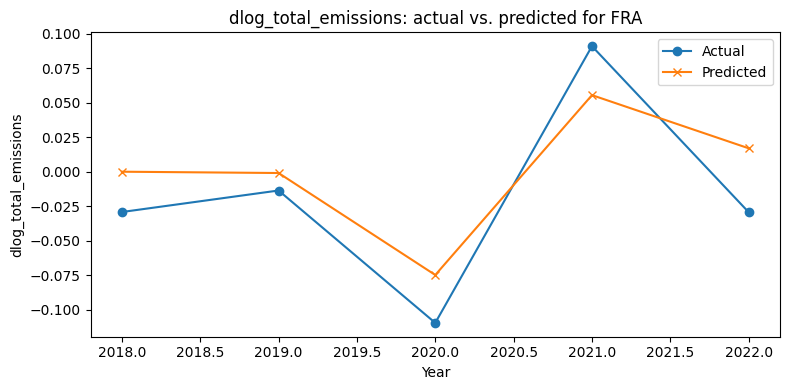

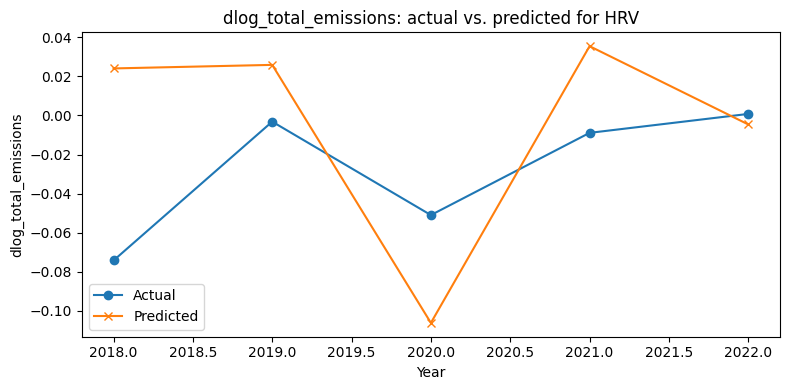

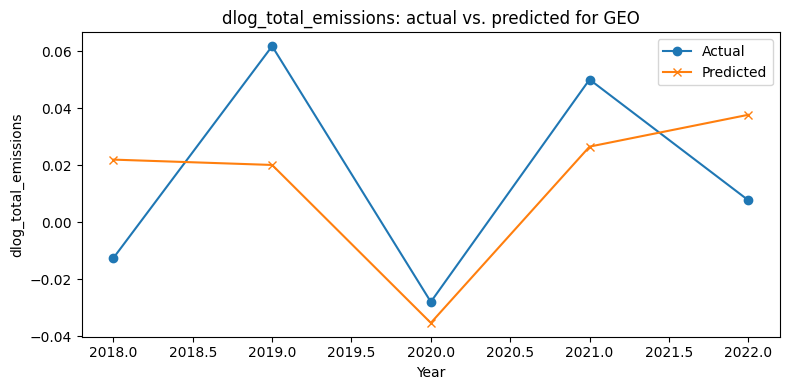

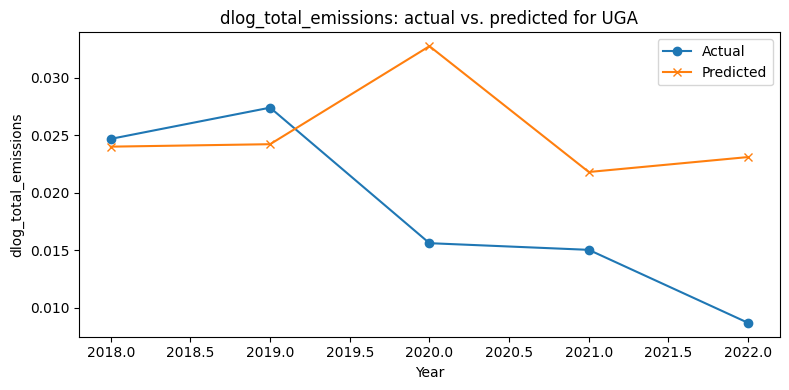

In [56]:
import matplotlib.pyplot as plt

def plot_actual_vs_predicted_country(test_df, X_test, y_test, best_estimators, country='USA', model_name='rf'):
    """
    Plot actual vs. predicted dlog_total_emissions for a specific country and model.

    Parameters:
        test_df (pd.DataFrame): The test set with 'iso_alpha_3' and 'year' columns.
        X_test (pd.DataFrame): Test features.
        y_test (pd.Series): Test target values.
        best_estimators (dict): Dict of trained models, e.g. {'rf': ..., 'gb': ..., 'mlp': ...}
        country (str): ISO alpha-3 code for the country to plot.
        model_name (str): Key for the model to use ('rf', 'gb', or 'mlp').
    """
    mask = test_df['iso_alpha_3'] == country
    X_country = X_test[mask]
    years     = test_df.loc[mask, 'year']
    actual    = y_test[mask]
    model = best_estimators[model_name]
    predicted = model.predict(X_country)

    comp = (
        pd.DataFrame({
            'year':      years,
            'actual':    actual,
            'predicted': predicted
        })
        .sort_values('year')
        .reset_index(drop=True)
    )

    # print(comp)

    plt.figure(figsize=(8, 4))
    plt.plot(comp['year'], comp['actual'],    marker='o', label='Actual')
    plt.plot(comp['year'], comp['predicted'], marker='x', label='Predicted')
    plt.title(f"dlog_total_emissions: actual vs. predicted for {country}")
    plt.xlabel("Year")
    plt.ylabel("dlog_total_emissions")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_actual_vs_predicted_country(test, X_test, y_test, best_estimators, country='USA', model_name='rf')
plot_actual_vs_predicted_country(test, X_test, y_test, best_estimators, country='MEX', model_name='rf')
plot_actual_vs_predicted_country(test, X_test, y_test, best_estimators, country='FRA', model_name='rf') 
plot_actual_vs_predicted_country(test, X_test, y_test, best_estimators, country='HRV', model_name='rf')
plot_actual_vs_predicted_country(test, X_test, y_test, best_estimators, country='GEO', model_name='rf')
plot_actual_vs_predicted_country(test, X_test, y_test, best_estimators, country='UGA', model_name='rf')


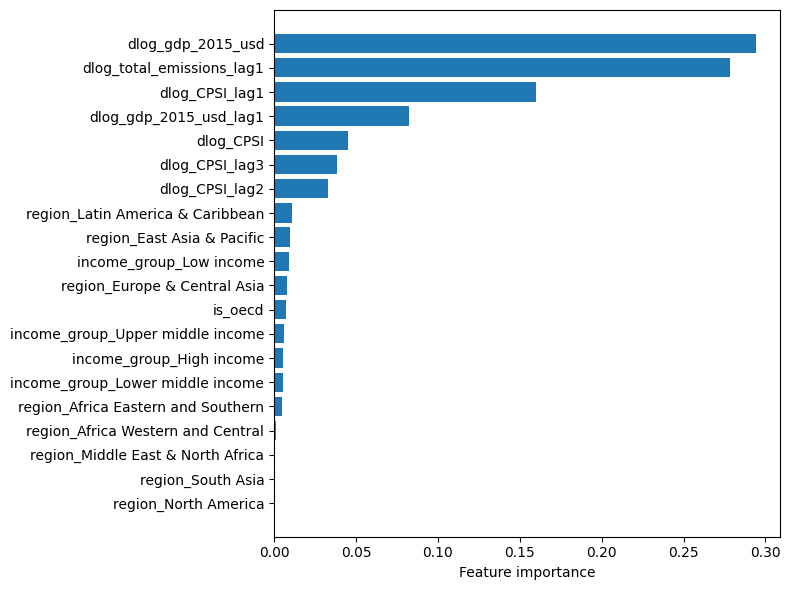

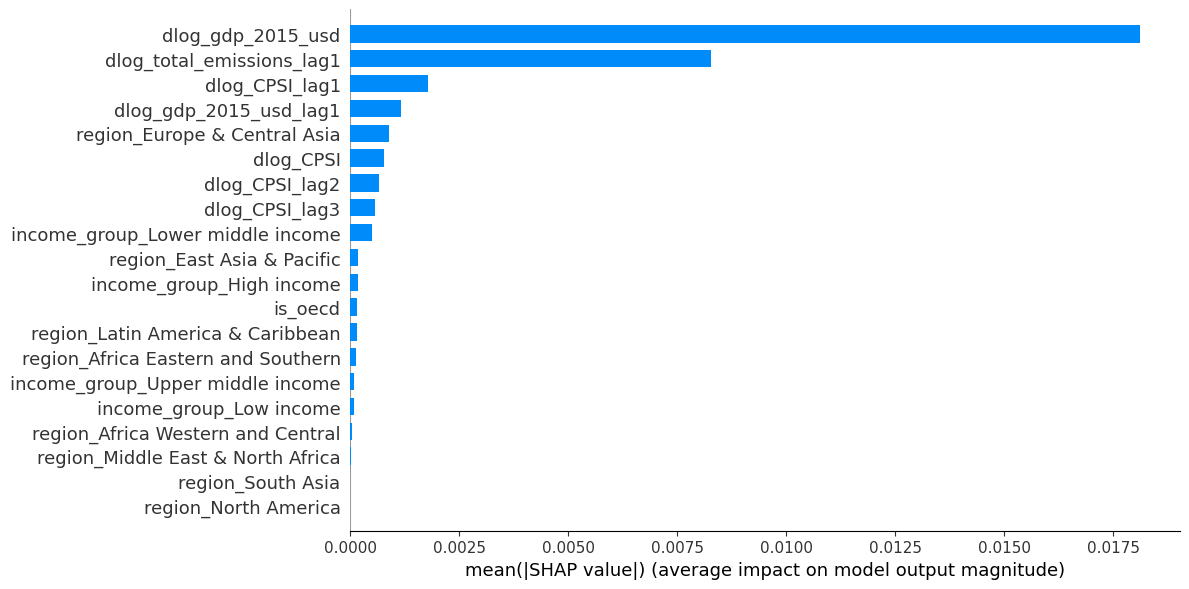

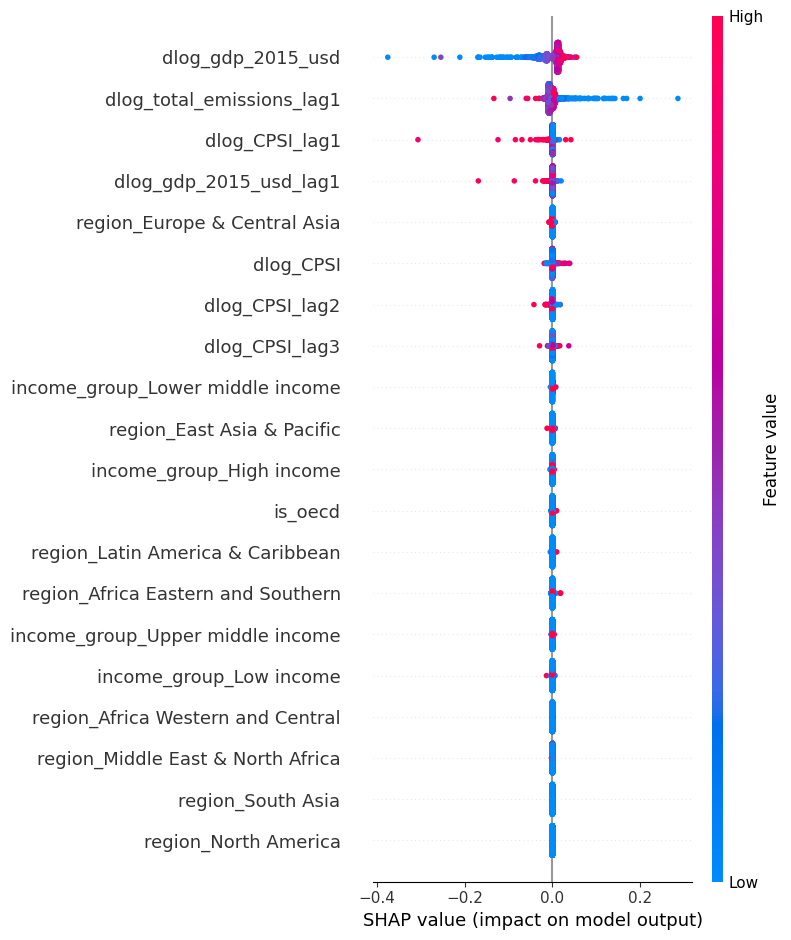

In [57]:
import shap
import numpy as np

rf_pipe = best_estimators['rf']
preprocessor = rf_pipe.named_steps['pre']       # ColumnTransformer
rf_model    = rf_pipe.named_steps['model']     # RandomForestRegressor


cat_ohe = preprocessor.named_transformers_['cat']  # OneHotEncoder
cat_features = list(cat_ohe.get_feature_names_out(CATEGORICAL))
num_features = NUMERIC
feature_names = cat_features + num_features

importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(8, 6))
plt.barh([feature_names[i] for i in indices], importances[indices])
plt.xlabel("Feature importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


X_train_trans = preprocessor.transform(X_train)
X_train_df = pd.DataFrame(
    X_train_trans,
    columns=feature_names,
    index=X_train.index
)


explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_train_trans)

shap.summary_plot(
    shap_values,
    X_train_df,
    plot_type="bar",
    show=False,
    plot_size=(12, 6)
)
plt.tight_layout()
plt.show()


shap.summary_plot(
    shap_values,
    X_train_df,
    show=False
)
plt.tight_layout()
plt.show()
